In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
import pandas as pd


def load_h5_simple(filename):
    data = {}
    with h5py.File(filename, "r") as f:
        for group in f:
            data[group] = {}
            for sub in f[group]:
                if isinstance(f[group][sub], h5py.Group):
                    data[group][sub] = {
                        dset: f[group][sub][dset][:]
                        for dset in f[group][sub]
                    }
                else:
                    data[group][sub] = f[group][sub][:]
    return data

data = load_h5_simple("BBH_injections_and_fishermatrix.h5")

In [2]:
print("data.keys():", data.keys())
print("data['injections'].keys():", data['injections'].keys())
print("data['fisher'].keys():", data['fisher'].keys())

data.keys(): dict_keys(['fisher', 'injections'])
data['injections'].keys(): dict_keys(['chi_1', 'chi_1_in_plane', 'chi_2', 'chi_2_in_plane', 'chi_eff', 'chi_p', 'chirp_mass', 'chirp_mass_source', 'dec', 'lambda_1', 'lambda_2', 'luminosity_distance', 'mass_1', 'mass_1_source', 'mass_2', 'mass_2_source', 'mass_ratio', 'p_m1', 'p_q_given_m1', 'p_z', 'phase', 'psi', 'ra', 'redshift', 'reference_frequency', 'spin_1x', 'spin_1y', 'spin_1z', 'spin_2x', 'spin_2y', 'spin_2z', 'symmetric_mass_ratio', 'theta_jn', 'total_mass', 'total_mass_source'])
data['fisher'].keys(): dict_keys(['A_BBH_ETD-CE20-CE40', 'A_BBH_ETD-CE20-LI', 'A_BBH_ETD-CE40-LI', 'B_BBH_ET2L-CE20', 'B_BBH_ET2L-CE40', 'B_BBH_ET2L-LI', 'C_BBH_ET1L-CE20-LI', 'C_BBH_ET1L-CE40-CE20', 'C_BBH_ET1L-CE40-LI'])


## Histograms

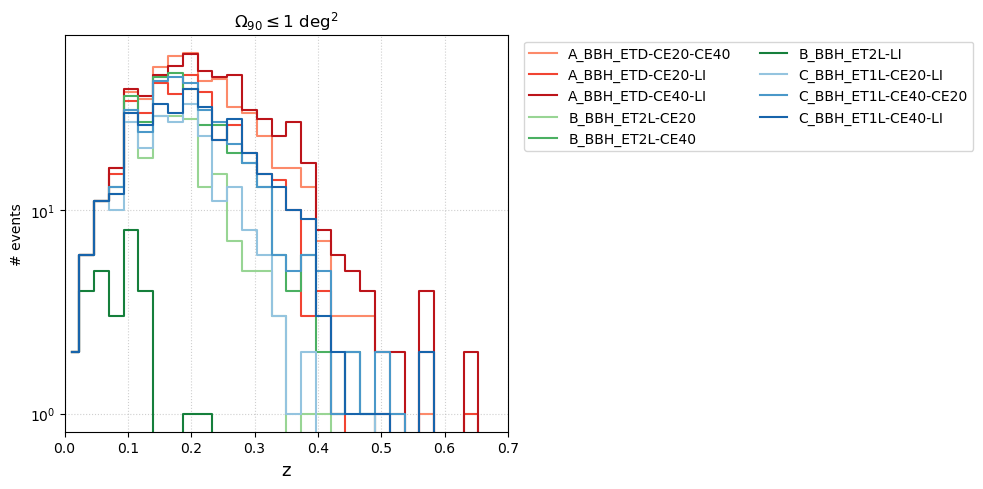

In [2]:
# 0.1 deg^2

keys_order = [
    'A_BBH_ETD-CE20-CE40',
    'A_BBH_ETD-CE20-LI',
    'A_BBH_ETD-CE40-LI',
    'B_BBH_ET2L-CE20',
    'B_BBH_ET2L-CE40',
    'B_BBH_ET2L-LI',
    'C_BBH_ET1L-CE20-LI',
    'C_BBH_ET1L-CE40-CE20',
    'C_BBH_ET1L-CE40-LI'
]

reds   = plt.cm.Reds(np.linspace(0.4, 0.8, 3))
greens = plt.cm.Greens(np.linspace(0.4, 0.8, 3))
blues  = plt.cm.Blues(np.linspace(0.4, 0.8, 3))
colors = np.vstack([reds, greens, blues])  # 9 x 4 RGBA

threshold = 0.1
n_bins = 30
z_min = 0.0
z_max = 0.7  
figsize = (10,5)

redshifts = np.asarray(data['injections']['redshift'])
if z_max is None:
    z_max = np.nanmax(redshifts)
bins = np.linspace(z_min, z_max, n_bins+1)
bincenters = 0.5*(bins[:-1] + bins[1:])

plt.figure(figsize=figsize)
plt.yscale('log')
plt.xlabel('z', fontsize=13)
plt.xlim(z_min, z_max)
plt.grid(which='major', linestyle=':', alpha=0.6)
plt.title(r'$\Omega_{90} \leq 1\ \mathrm{deg}^2$')

fisher_dict = data['fisher']

for i, k in enumerate(keys_order):
    df = fisher_dict[k]
    skyArea = np.asarray(df["skyArea"])
    zs = redshifts[:len(skyArea)]
    mask = np.isfinite(skyArea) & np.isfinite(zs)
    mask &= (skyArea <= threshold)
    counts, _ = np.histogram(zs[mask], bins=bins)
    plt.step(bincenters, counts, where='mid', label=k, color=colors[i])

plt.ylabel('# events')
plt.gca().yaxis.set_major_locator(ticker.LogLocator(base=10.0))
plt.gca().yaxis.set_minor_locator(ticker.NullLocator())
plt.legend(ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('1deg2hist.png', dpi=300, bbox_inches='tight')
plt.show()

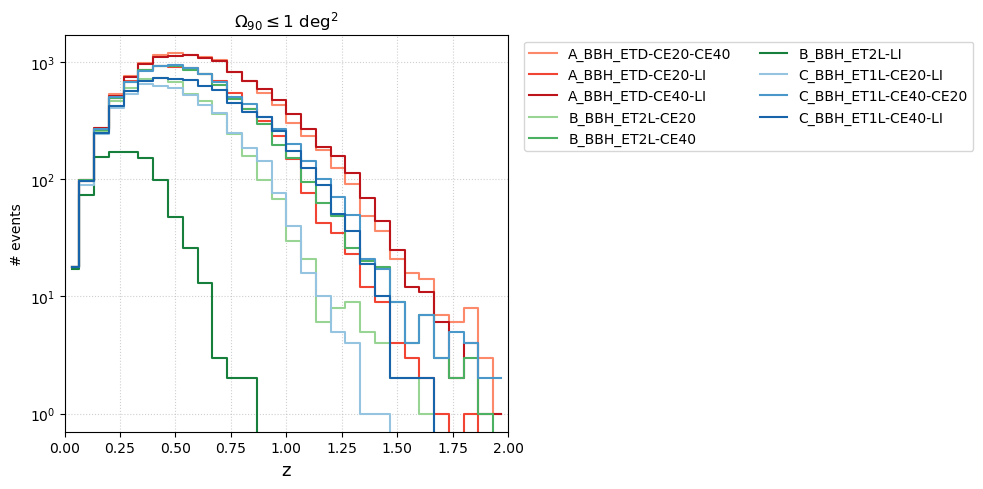

In [3]:
# 10 deg^2

keys_order = [
    'A_BBH_ETD-CE20-CE40',
    'A_BBH_ETD-CE20-LI',
    'A_BBH_ETD-CE40-LI',
    'B_BBH_ET2L-CE20',
    'B_BBH_ET2L-CE40',
    'B_BBH_ET2L-LI',
    'C_BBH_ET1L-CE20-LI',
    'C_BBH_ET1L-CE40-CE20',
    'C_BBH_ET1L-CE40-LI'
]

reds   = plt.cm.Reds(np.linspace(0.4, 0.8, 3))
greens = plt.cm.Greens(np.linspace(0.4, 0.8, 3))
blues  = plt.cm.Blues(np.linspace(0.4, 0.8, 3))
colors = np.vstack([reds, greens, blues])  # 9 x 4 RGBA

threshold = 1.0
n_bins = 30
z_min = 0.0
z_max = 2  
figsize = (10,5)

redshifts = np.asarray(data['injections']['redshift'])
if z_max is None:
    z_max = np.nanmax(redshifts)
bins = np.linspace(z_min, z_max, n_bins+1)
bincenters = 0.5*(bins[:-1] + bins[1:])

plt.figure(figsize=figsize)
plt.yscale('log')
plt.xlabel('z', fontsize=13)
plt.xlim(z_min, z_max)
plt.grid(which='major', linestyle=':', alpha=0.6)
plt.title(r'$\Omega_{90} \leq 1\ \mathrm{deg}^2$')

fisher_dict = data['fisher']

for i, k in enumerate(keys_order):
    df = fisher_dict[k]
    skyArea = np.asarray(df["skyArea"])
    zs = redshifts[:len(skyArea)]
    mask = np.isfinite(skyArea) & np.isfinite(zs)
    mask &= (skyArea <= threshold)
    counts, _ = np.histogram(zs[mask], bins=bins)
    plt.step(bincenters, counts, where='mid', label=k, color=colors[i])

plt.ylabel('# events')
plt.gca().yaxis.set_major_locator(ticker.LogLocator(base=10.0))
plt.gca().yaxis.set_minor_locator(ticker.NullLocator())
plt.legend(ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('1deg2hist.png', dpi=300, bbox_inches='tight')
plt.show()

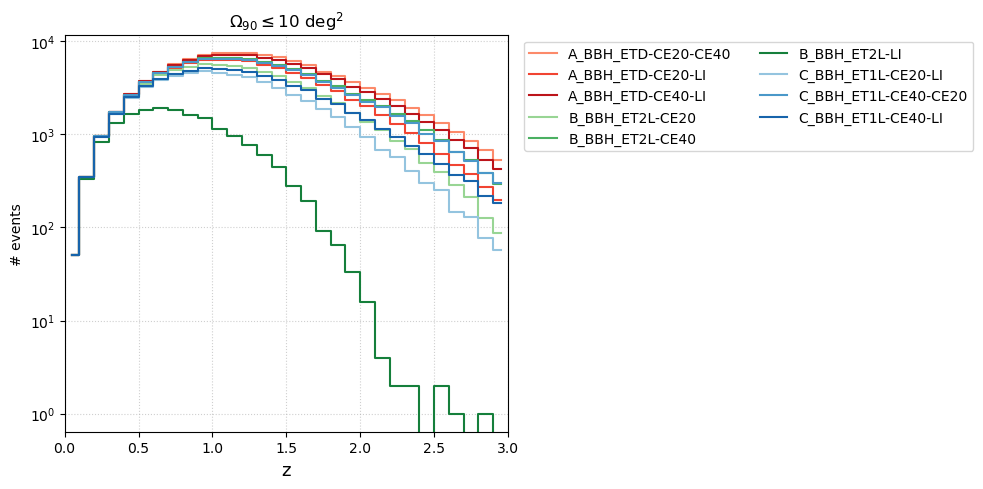

In [4]:
# 10 deg^2
threshold = 10.0
n_bins = 30
z_min = 0.0
z_max = 3
bins = np.linspace(z_min, z_max, n_bins+1)
bincenters = 0.5*(bins[:-1] + bins[1:])

plt.figure(figsize=(10,5))
plt.yscale('log')
plt.xlabel('z', fontsize=13)
plt.xlim(z_min, z_max)
plt.grid(which='major', linestyle=':', alpha=0.6)
plt.title(r'$\Omega_{90} \leq 10\ \mathrm{deg}^2$')

for i, k in enumerate(keys_order):
    df = fisher_dict[k]
    skyArea = np.asarray(df["skyArea"])
    zs = redshifts[:len(skyArea)]
    mask = np.isfinite(skyArea) & np.isfinite(zs)
    mask &= (skyArea <= threshold)
    counts, _ = np.histogram(zs[mask], bins=bins)
    plt.step(bincenters, counts, where='mid', label=k, color=colors[i])

plt.ylabel('# events')
plt.gca().yaxis.set_major_locator(ticker.LogLocator(base=10.0))
plt.gca().yaxis.set_minor_locator(ticker.NullLocator())
plt.legend(ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('10deg2hist.png', dpi=300, bbox_inches='tight')
plt.show()

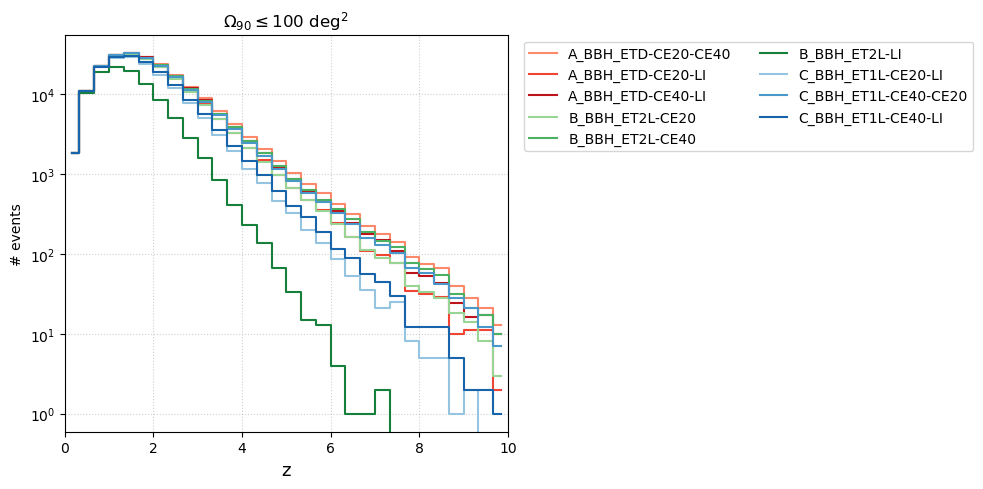

In [5]:
# 100 deg^2
threshold = 100.0
n_bins = 30
z_min = 0.0
z_max = 10
bins = np.linspace(z_min, z_max, n_bins+1)
bincenters = 0.5*(bins[:-1] + bins[1:])

plt.figure(figsize=(10,5))
plt.yscale('log')
plt.xlabel('z', fontsize=13)
plt.xlim(z_min, z_max)
plt.grid(which='major', linestyle=':', alpha=0.6)
plt.title(r'$\Omega_{90} \leq 100\ \mathrm{deg}^2$')

for i, k in enumerate(keys_order):
    df = fisher_dict[k]
    skyArea = np.asarray(df["skyArea"])
    zs = redshifts[:len(skyArea)]
    mask = np.isfinite(skyArea) & np.isfinite(zs)
    mask &= (skyArea <= threshold)
    counts, _ = np.histogram(zs[mask], bins=bins)
    plt.step(bincenters, counts, where='mid', label=k, color=colors[i])

plt.ylabel('# events')
plt.gca().yaxis.set_major_locator(ticker.LogLocator(base=10.0))
plt.gca().yaxis.set_minor_locator(ticker.NullLocator())
plt.legend(ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('100deg2hist.png', dpi=300, bbox_inches='tight')

plt.show()

# Tables

In [6]:
def make_table(data, threshold):
    fisher_dict = data['fisher']
    redshifts = np.asarray(data['injections']['redshift'])

    results = {'Number': [], 'Median z': [], 'Maximum z': []}

    for k in keys_order:
        df = fisher_dict[k]
        skyArea = np.asarray(df["skyArea"])
        zs = redshifts[:len(skyArea)]

        mask = np.isfinite(skyArea) & np.isfinite(zs)
        mask &= (skyArea <= threshold)

        selected_zs = zs[mask]
        N = selected_zs.size

        if N == 0:
            median_z = np.nan
            max_z = np.nan
        else:
            median_z = np.median(selected_zs)
            max_z = np.max(selected_zs)

        results['Number'].append(int(N))
        results['Median z'].append(median_z)
        results['Maximum z'].append(max_z)

    # DataFrame numerico (non convertiamo nulla in stringa)
    df_out = pd.DataFrame(results, index=keys_order).T
    df_out.loc['Number'] = df_out.loc['Number'].astype(int)

    # SOLO formattazione visuale (no cambio dtype)
    return df_out.style.format({
        'Median z': "{:.3f}",
        'Maximum z': "{:.3f}"
    })


# stampa delle tre tabelle
for thr in [1.0, 10.0, 100.0]:
    print(f"\n=====  ΔΩ90 ≤ {int(thr)} deg²  =====")
    display(make_table(data, thr))


=====  ΔΩ90 ≤ 1 deg²  =====


,A_BBH_ETD-CE20-CE40,A_BBH_ETD-CE20-LI,A_BBH_ETD-CE40-LI,B_BBH_ET2L-CE20,B_BBH_ET2L-CE40,B_BBH_ET2L-LI,C_BBH_ET1L-CE20-LI,C_BBH_ET1L-CE40-CE20,C_BBH_ET1L-CE40-LI
Number,11890.000000,8483.000000,11949.000000,5575.000000,8358.000000,933.000000,5200.000000,8787.000000,7315.000000
Median z,0.586624,0.532885,0.598327,0.457777,0.525686,0.286892,0.470908,0.543594,0.550340
Maximum z,2.589400,1.836576,2.589400,1.655236,1.931407,0.855331,1.415361,2.034893,1.613830



=====  ΔΩ90 ≤ 10 deg²  =====


,A_BBH_ETD-CE20-CE40,A_BBH_ETD-CE20-LI,A_BBH_ETD-CE40-LI,B_BBH_ET2L-CE20,B_BBH_ET2L-CE40,B_BBH_ET2L-LI,C_BBH_ET1L-CE20-LI,C_BBH_ET1L-CE40-CE20,C_BBH_ET1L-CE40-LI
Number,112184.000000,86703.000000,104880.000000,73270.000000,94130.000000,17436.000000,58730.000000,92341.000000,69103.000000
Median z,1.303486,1.196388,1.275421,1.130090,1.235924,0.745224,1.077976,1.230160,1.148593
Maximum z,10.653598,4.768003,5.570867,5.414556,6.535199,3.020041,4.107707,6.420019,4.767958



=====  ΔΩ90 ≤ 100 deg²  =====


,A_BBH_ETD-CE20-CE40,A_BBH_ETD-CE20-LI,A_BBH_ETD-CE40-LI,B_BBH_ET2L-CE20,B_BBH_ET2L-CE40,B_BBH_ET2L-LI,C_BBH_ET1L-CE20-LI,C_BBH_ET1L-CE40-CE20,C_BBH_ET1L-CE40-LI
Number,210801.000000,195815.000000,205267.000000,193781.000000,203660.000000,105096.000000,164877.000000,201390.000000,173396.000000
Median z,1.738238,1.672589,1.713387,1.667273,1.709546,1.326356,1.558791,1.699325,1.591719
Maximum z,14.859418,13.428553,14.751062,13.428553,14.751062,7.206216,9.267286,14.751062,11.262793


# Choice of bilby runs

In [3]:
import numpy as np
import pandas as pd

primary_network = 'A_BBH_ETD-CE20-CE40'
top_n = 2000
subset_fraction = 0.075

fisher = data['fisher']
inj = data['injections']
dfp = fisher[primary_network]

skyArea = np.asarray(dfp['skyArea'])
SNR = np.asarray(dfp['SNR'])
redshifts = np.asarray(inj['redshift'])

L = len(skyArea)
zs = redshifts[:L]

order_snr = np.argsort(-SNR)
top_idx = order_snr[:top_n]

N_total = len(redshifts)
subset_size = int(round(subset_fraction * N_total))

top_sky = skyArea[top_idx]
order_sky = np.argsort(top_sky)
subset_idx = top_idx[order_sky[:subset_size]]
dL = np.asarray(inj['luminosity_distance'])
mask_dL = dL[subset_idx] > 600.0
subset_idx = subset_idx[mask_dL]

print("Subset size (dL > 600 Mpc):", len(subset_idx))
print()

print("Subset size:", len(subset_idx))
print()

rows = []

for idx in subset_idx:
    row = {
        'idx': int(idx),
        'skyArea': float(skyArea[idx]),
        'SNR': float(SNR[idx]),
        'redshift': inj['redshift'][idx],
        'mass_1': inj['mass_1'][idx],
        'mass_2': inj['mass_2'][idx],
        'mass_1_source': inj['mass_1_source'][idx],
        'mass_2_source': inj['mass_2_source'][idx],
        'chirp_mass': inj['chirp_mass'][idx],
        'chi_eff': inj['chi_eff'][idx],
        'chi_p': inj['chi_p'][idx],
        'luminosity_distance': inj['luminosity_distance'][idx],
        'theta_jn': inj['theta_jn'][idx],
        'psi': inj['psi'][idx],
        'phase': inj['phase'][idx],
        'ra': inj['ra'][idx],
        'dec': inj['dec'][idx]
    }
    rows.append(row)

df_subset = pd.DataFrame(rows).set_index('idx')

display(df_subset.head(2))


best_idx = subset_idx[1]

s1x = inj['spin_1x'][best_idx]
s1y = inj['spin_1y'][best_idx]
s1z = inj['spin_1z'][best_idx]

s2x = inj['spin_2x'][best_idx]
s2y = inj['spin_2y'][best_idx]
s2z = inj['spin_2z'][best_idx]

a_1 = np.sqrt(s1x**2 + s1y**2 + s1z**2)
a_2 = np.sqrt(s2x**2 + s2y**2 + s2z**2)

tilt_1 = np.arccos(s1z / a_1) if a_1 > 0 else 0.0
tilt_2 = np.arccos(s2z / a_2) if a_2 > 0 else 0.0

phi1 = np.arctan2(s1y, s1x)
phi2 = np.arctan2(s2y, s2x)
phi_12 = np.mod(phi2 - phi1, 2*np.pi)

print("\ninjection_parameters = dict(")
print(f"    mass_1={inj['mass_1'][best_idx]:.6f},")
print(f"    mass_2={inj['mass_2'][best_idx]:.6f},")
print(f"    a_1={a_1:.6f},")
print(f"    a_2={a_2:.6f},")
print(f"    tilt_1={tilt_1:.6f},")
print(f"    tilt_2={tilt_2:.6f},")
print(f"    phi_12={phi_12:.6f},")
print(f"    phi_jl=0.0,")
print(f"    luminosity_distance={inj['luminosity_distance'][best_idx]:.6f},")
print(f"    theta_jn={inj['theta_jn'][best_idx]:.6f},")
print(f"    psi={inj['psi'][best_idx]:.6f},")
print(f"    phase={inj['phase'][best_idx]:.6f},")
print(f"    geocent_time=0.0,")
print(f"    ra={inj['ra'][best_idx]:.6f},")
print(f"    dec={inj['dec'][best_idx]:.6f},")
print(")")

Subset size (dL > 600 Mpc): 1904

Subset size: 1904



,skyArea,SNR,redshift,mass_1,mass_2,mass_1_source,mass_2_source,chirp_mass,chi_eff,chi_p,luminosity_distance,theta_jn,psi,phase,ra,dec
idx,,,,,,,,,,,,,,,,
28352,0.007967,1734.491422,0.134167,44.810152,33.068367,39.509324,29.156537,33.434125,0.145147,0.0,652.021812,0.903708,2.549658,0.792172,4.796459,0.476191
49519,0.011523,1366.641153,0.160412,33.325256,18.720100,28.718472,16.132289,21.566149,0.203039,0.0,792.381276,2.463650,1.045656,1.696272,4.459685,0.796240



injection_parameters = dict(
    mass_1=33.325256,
    mass_2=18.720100,
    a_1=0.361861,
    a_2=0.079694,
    tilt_1=0.000000,
    tilt_2=3.141593,
    phi_12=0.000000,
    phi_jl=0.0,
    luminosity_distance=792.381276,
    theta_jn=2.463650,
    psi=1.045656,
    phase=1.696272,
    geocent_time=0.0,
    ra=4.459685,
    dec=0.796240,
)
